In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", 10)
pd.options.display.float_format = '{:.2f}'.format
sns.set()

In [100]:
#1. Get data

df_train = pd.read_csv('fashion-mnist_train.csv')
df_test = pd.read_csv('fashion-mnist_test.csv')
df_train.head()

train = df_train.to_numpy()
test = df_test.to_numpy()
train

array([[2, 0, 0, ..., 0, 0, 0],
       [9, 0, 0, ..., 0, 0, 0],
       [6, 0, 0, ..., 0, 0, 0],
       ...,
       [8, 0, 0, ..., 0, 0, 0],
       [8, 0, 0, ..., 0, 0, 0],
       [7, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [101]:
ms = train.shape[0]
ns = train.shape[1]
mt, nt = test.shape

X_train = train[:,1:ns]
X_train = (X_train.T)/255
y_train = train[:,0]
X_test = test[:,1:nt]
X_test = (X_test.T)/255
y_test = test[:,0]
X_train

neur1 = 128
neur2 = 64
neur3 = 32
neur4 = 10

m = X_train.shape[1]   #number of training examples
n = X_train.shape[0]   #number of features (pixels)

In [102]:
# Dataset Distribution

In [103]:
def init_params():
    W1 = np.random.uniform(-0.5, 0.5, (neur1, n))
    b1 = np.random.uniform(-0.5, 0.5, (neur1, 1))
    W2 = np.random.uniform(-0.5, 0.5, (neur2, neur1))
    b2 = np.random.uniform(-0.5, 0.5, (neur2, 1))
    W3 = np.random.uniform(-0.5, 0.5, (neur3, neur2))
    b3 = np.random.uniform(-0.5, 0.5, (neur3, 1))
    W4 = np.random.uniform(-0.5, 0.5, (neur4, neur3))
    b4 = np.random.uniform(-0.5, 0.5, (neur4, 1))
    return W1, b1, W2, b2, W3, b3, W4, b4

In [104]:
#Activation Functions
def ReLU(z):
    return np.maximum(z,0)

def dReLU(z):
    return z>0

def LeakyReLU(vector, alpha=0.01):
    vector = np.array(vector)
    return np.where(vector > 0, vector, alpha * vector)

def dLeakyReLU(vector, alpha=0.01):
    vector = np.array(vector)
    return np.where(vector > 0, 1, alpha)

def softmax(vector):
    vector = np.array(vector)
    e_x = np.exp(vector - np.max(vector, axis=0, keepdims=True))
    return e_x / e_x.sum(axis=0, keepdims=True)

def dSoftmax(vector):
    vector = np.array(vector)
    s = softmax(vector)
    return np.diagflat(s) - np.outer(s, s)

def tanh(vector):
    vector = np.array(vector)
    return np.tanh(vector)

def dTanh(vector):
    vector = np.array(vector)
    return 1 - np.tanh(vector)**2

def sigmoid(vector):
    vector = np.array(vector)
    return 1 / (1 + np.exp(-vector))

def dSigmoid(vector):
    vector = np.array(vector)
    s = sigmoid(vector)
    return s * (1 - s)


In [105]:
#One Hot Encoding
def one_hot(Y):
    init_one = np.zeros((neur4, m))  # Change neur2 to neur4
    init_one[Y[np.arange(m)], np.arange(m)] = 1
    return init_one

In [106]:
#Forward Propagation
def forward_pass(W1,b1,W2,b2,W3,b3,W4,b4,X):
    Z1 = W1.dot(X) + b1    #(neur1,m)
    A1 = ReLU(Z1)          #(neur1,m)
    Z2 = W2.dot(A1) + b2   #y_hat  (neur2,m)
    # Z2 = 7*(Z2 - np.mean(Z2))/(np.std(Z2)) 
    A2 = softmax(Z2)       #p(y_hat) (neur2,m)
    Z3 = W3.dot(A2) + b3   # (neur3, m)
    A3 = ReLU(Z3)          # (neur3, m)
    Z4 = W4.dot(A3) + b4   # (neur4, m)
    A4 = softmax(Z4)       # (neur4, m)
    return Z1, A1, Z2, A2, Z3, A3, Z4, A4

In [107]:
#Back Propagation
def crossentropy_backpropagation(Z1, A1, Z2, A2, Z3, A3, Z4, A4, W4, W3, W2, X, y):
    Y_one_hot = one_hot(y)
    
    dL_dZ4 = A4 - Y_one_hot            # (neur4, m)
    dL_db4 = (1 / m) * (np.sum(dL_dZ4, axis=1).reshape(neur4, 1))    # (neur4, 1)
    dL_dW4 = (1 / m) * (dL_dZ4.dot(A3.T))         # (neur4, neur3)
    
    dL_dZ3 = W4.T.dot(dL_dZ4) * dReLU(Z3)  # (neur3, m)
    dL_db3 = (1 / m) * (np.sum(dL_dZ3, axis=1).reshape(neur3, 1))    # (neur3, 1)
    dL_dW3 = (1 / m) * (dL_dZ3.dot(A2.T))          # (neur3, neur2)
    
    dL_dZ2 = W3.T.dot(dL_dZ3) * dReLU(Z2)  # (neur2, m)
    dL_db2 = (1 / m) * (np.sum(dL_dZ2, axis=1).reshape(neur2, 1))    # (neur2, 1)
    dL_dW2 = (1 / m) * (dL_dZ2.dot(A1.T))          # (neur2, neur1)
    
    dL_dZ1 = W2.T.dot(dL_dZ2) * dReLU(Z1)  # (neur1, m)
    dL_db1 = (1 / m) * (np.sum(dL_dZ1, axis=1).reshape(neur1, 1))    # (neur1, 1)
    dL_dW1 = (1 / m) * (dL_dZ1.dot(X.T))          # (neur1, n)
    
    return dL_db4, dL_dW4, dL_db3, dL_dW3, dL_db2, dL_dW2, dL_db1, dL_dW1


In [108]:
#Update Parameters
def update_parameters(W1, b1, W2, b2, W3, b3, W4, b4, dL_db1, dL_dW1, dL_db2, dL_dW2, dL_db3, dL_dW3, dL_db4, dL_dW4, alpha):
    W1 = W1 - alpha * dL_dW1
    b1 = b1 - alpha * dL_db1
    W2 = W2 - alpha * dL_dW2
    b2 = b2 - alpha * dL_db2
    W3 = W3 - alpha * dL_dW3
    b3 = b3 - alpha * dL_db3
    W4 = W4 - alpha * dL_dW4
    b4 = b4 - alpha * dL_db4
    return W1, b1, W2, b2, W3, b3, W4, b4


In [109]:
#Predictions
def get_predictions(A4):
    return np.argmax(A4,0)

In [110]:
#Accuracy
def get_accuracy(predictions,y):
    print(predictions,y)
    return np.sum(predictions == y)/y.size

In [111]:
def compute_loss(A4, Y):
    return -np.sum(Y * np.log(A4)) / m

In [112]:
#Gradient descent
def gradient_descent(X, y, epochs, alpha):
    W1, b1, W2, b2, W3, b3, W4, b4 = init_params()

    accuracy_scores = []
    loss_list = []
    
    for i in range(epochs):
        Z1, A1, Z2, A2, Z3, A3, Z4, A4 = forward_pass(W1, b1, W2, b2, W3, b3, W4, b4, X)
        
        loss = compute_loss(A4, one_hot(y))
        loss_list.append(loss)
        
        dL_db4, dL_dW4, dL_db3, dL_dW3, dL_db2, dL_dW2, dL_db1, dL_dW1 = crossentropy_backpropagation(Z1, A1, Z2, A2, Z3, A3, Z4, A4, W4, W3, W2, X, y)
        
        W1, b1, W2, b2, W3, b3, W4, b4 = update_parameters(W1, b1, W2, b2, W3, b3, W4, b4, dL_db1, dL_dW1, dL_db2, dL_dW2, dL_db3, dL_dW3, dL_db4, dL_dW4, alpha)

        accuracy = get_accuracy(get_predictions(A4),y)
        accuracy_scores.append(accuracy)
        
        if i % 5 == 0:
            print("Iteration: ", i)
            print("Loss: ", loss)
            print("Accuracy: ", get_accuracy(get_predictions(A4), y))
            print('*' * 20)
    return W1, b1, W2, b2, W3, b3, W4, b4, Z4, A4, accuracy_scores, loss_list

In [113]:
W1, b1, W2, b2, W3, b3, W4, b4, Z4, A4, accuracy, loss = gradient_descent(X_train, y_train, 1001, 0.1)

[8 9 9 ... 6 8 9] [2 9 6 ... 8 8 7]
Iteration:  0
Loss:  2.4084868724205433
[8 9 9 ... 6 8 9] [2 9 6 ... 8 8 7]
Accuracy:  0.12501666666666666
********************
[8 9 6 ... 9 8 6] [2 9 6 ... 8 8 7]
[8 9 2 ... 2 8 6] [2 9 6 ... 8 8 7]
[2 6 2 ... 2 8 6] [2 9 6 ... 8 8 7]
[8 8 2 ... 6 8 6] [2 9 6 ... 8 8 7]
[2 8 2 ... 2 8 6] [2 9 6 ... 8 8 7]
Iteration:  5
Loss:  2.261349414214702
[2 8 2 ... 2 8 6] [2 9 6 ... 8 8 7]
Accuracy:  0.18288333333333334
********************
[6 8 2 ... 6 8 6] [2 9 6 ... 8 8 7]
[2 8 2 ... 2 2 6] [2 9 6 ... 8 8 7]
[2 6 2 ... 6 6 9] [2 9 6 ... 8 8 7]
[6 9 6 ... 2 6 8] [2 9 6 ... 8 8 7]
[6 9 6 ... 6 6 8] [2 9 6 ... 8 8 7]
Iteration:  10
Loss:  2.2275992655803756
[6 9 6 ... 6 6 8] [2 9 6 ... 8 8 7]
Accuracy:  0.18788333333333335
********************
[2 9 2 ... 2 2 8] [2 9 6 ... 8 8 7]
[6 9 6 ... 6 6 5] [2 9 6 ... 8 8 7]
[2 5 6 ... 6 2 5] [2 9 6 ... 8 8 7]
[2 9 2 ... 2 2 5] [2 9 6 ... 8 8 7]
[6 5 6 ... 6 6 5] [2 9 6 ... 8 8 7]
Iteration:  15
Loss:  2.209534992958394


In [114]:
#3. Validation
Z1, A1, Z2, A2, Z3, A3, Z4, A4 = forward_pass(W1, b1, W2, b2, W3, b3, W4, b4, X_test)
print("Test Accuracy: ", get_accuracy(get_predictions(A4), y_test))


[3 3 7 ... 7 7 3] [0 1 2 ... 8 8 1]
Test Accuracy:  0.1996


In [115]:
def make_predictions(X, W1, b1, W2, b2, W3, b3, W4, b4):
    _, _, _, _, _, _, _, A4 = forward_pass(W1, b1, W2, b2, W3, b3, W4, b4, X)
    predictions = get_predictions(A4)
    return predictions

def test_prediction(index, W1, b1, W2, b2, W3, b3, W4, b4):
    current_image = X_test[:, index, None]
    prediction = make_predictions(current_image, W1, b1, W2, b2, W3, b3, W4, b4)
    label = y_test[index]
    print('Prediction: ', prediction)
    print('Label: ', label)
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()


Prediction:  [5]
Label:  5


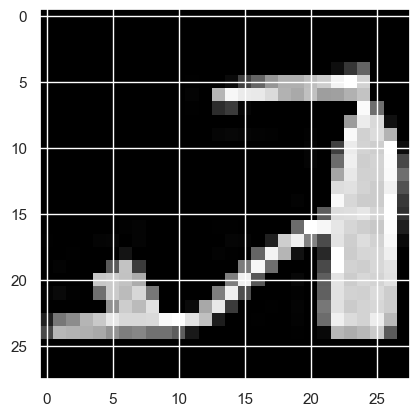

In [116]:
test_prediction(9800, W1, b1, W2, b2, W3, b3, W4, b4)

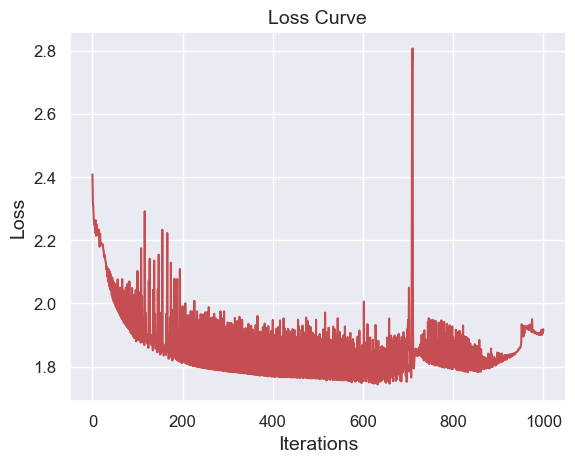

In [117]:
plt.plot(loss, linestyle='-', color='r')
plt.xlabel('Iterations', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.title('Loss Curve', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.show()

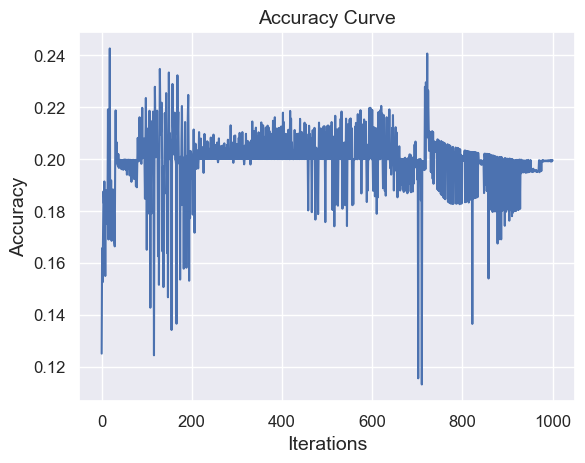

In [118]:
plt.plot(accuracy, linestyle='-', color='b')
plt.xlabel('Iterations', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.title('Accuracy Curve', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.show()

In [119]:
predictions = get_predictions(A4)
predictions[67]

7

In [120]:
confusion = confusion_matrix(y_test, predictions)
print(confusion)

[[  0   0   0 958   0   0   0  42   0   0]
 [  0   0   0 992   0   0   0   8   0   0]
 [  0   0   0 644   0   0   0 356   0   0]
 [  0   0   0 996   0   0   0   4   0   0]
 [  0   0   0 781   0   0   0 219   0   0]
 [  0   0   0  46   0   5   0 949   0   0]
 [  0   0   0 743   0   0   0 257   0   0]
 [  0   0   0   5   0   0   0 995   0   0]
 [  0   0   0 106   0   0   0 894   0   0]
 [  0   0   0  52   0   0   0 948   0   0]]


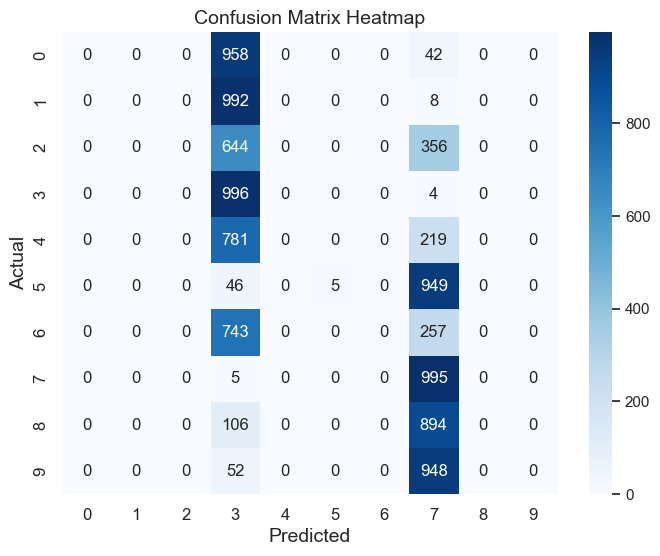

In [121]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('Actual', fontsize=14)
plt.title('Confusion Matrix Heatmap', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [122]:
report = classification_report(y_test, predictions, zero_division=0)
print(report)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1000
           1       0.00      0.00      0.00      1000
           2       0.00      0.00      0.00      1000
           3       0.19      1.00      0.32      1000
           4       0.00      0.00      0.00      1000
           5       1.00      0.01      0.01      1000
           6       0.00      0.00      0.00      1000
           7       0.21      0.99      0.35      1000
           8       0.00      0.00      0.00      1000
           9       0.00      0.00      0.00      1000

    accuracy                           0.20     10000
   macro avg       0.14      0.20      0.07     10000
weighted avg       0.14      0.20      0.07     10000

